# Restaurants — Exploratory Data Analysis

**Project 1 — Classification** · Machine Learning 1, WNE UW, 2025/2026

In this project we have to predict if a restaurant has closed or is still open. The target column is called `status_closed` (1 = closed, 0 = open). The grading metric on Kaggle is **balanced accuracy**.

Before we build any model, we want to look at the data carefully. This notebook is our exploratory data analysis (EDA). We try to answer these questions:

1. How big is the dataset and what does it look like?
2. How many closed vs open restaurants are there? Is the data balanced?
3. What types of features do we have (numbers, text, true/false)?
4. Where are the missing values and how many?
5. Which features look like they will help predict closure?
6. What preprocessing do we need to do before training models?

The answers we find here will guide us when we build models in `02_search.ipynb`.


## 1. Setup and loading the data

First we import the libraries we need. `pandas` is for working with tables, `numpy` for numbers, `matplotlib` and `seaborn` for plots. We also set a random seed so our results are reproducible.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

DATA_DIR = Path("data")
RANDOM_STATE = 42

Now we load the three CSV files: training data, test data, and a sample submission file (which shows the format we need to use when uploading our predictions to Kaggle).

In [2]:
train = pd.read_csv(DATA_DIR / "restaurants_train.csv")
test = pd.read_csv(DATA_DIR / "restaurants_test.csv")
sample_sub = pd.read_csv(DATA_DIR / "restaurant_sample_submission.csv")

print(f"Train shape:        {train.shape}")
print(f"Test shape:         {test.shape}")
print(f"Sample sub shape:   {sample_sub.shape}")

Train shape:        (33296, 86)
Test shape:         (8325, 85)
Sample sub shape:   (8325, 2)


The training set has 33,296 rows and 86 columns (85 features plus the target). The test set has 8,325 rows and only 85 columns because the target is hidden — that is what we need to predict.

Let's look at the first few rows to get a feel for the data.

In [3]:
train.head()

,restaurant_id,has_photo,user_ratings_total,price_level,category_top20,type_meal_takeaway,type_meal_delivery,type_bar,type_cafe,type_night_club,types_count,hours_open,hours_open_weekends,hours_open_workdays,days_evenings_only,days_mornings_only,weekends_only,workdays_only,rating_5,rating_4,rating_3,rating_2,rating_1,rating_avg,rating_std,tagcat_services,tagcat_amenities,tagcat_atmosphere,tagcat_offerings,tagcat_social_inclusivity,tagcat_payment_options,place_age_days,first_review_year_max,ratings_num_1m_prior,ratings_num_3m_prior,ratings_num_6m_prior,ratings_num_9m_prior,ratings_num_12m_prior,ratings_avg_1m_prior,ratings_avg_3m_prior,ratings_avg_6m_prior,ratings_avg_9m_prior,ratings_avg_12m_prior,lang_pl_count,rating_pl,rating_foreign,foreign_lang_share,rating_mean_pl,rating_mean_foreign,rating_mean_lang_ratio,review_has_text_pct,review_length_avg,review_length_std,catch_restaurant_count_500m,catch_rating_avg_500m,catch_place_age_days_500m,catch_restaurant_count_1000m,catch_rating_avg_1000m,catch_place_age_days_1000m,catch_restaurant_count_2000m,catch_rating_avg_2000m,catch_place_age_days_2000m,residents,restaurant_count,restaurants_per_capita,urbanization,poi_count_100m,poi_count_200m,poi_count_500m,poi_count_1000m,poi_count_2000m,gus_60297,gus_60528,gus_64428,gus_79214,gus_148074,gus_153354,gus_153398,gus_399257,gus_458173,gus_1548707_ratio,gus_60528_ratio,gus_1548707_net_ratio,gus_152173_ratio,affiliated,status_closed
0,753641611,True,408.0,1.0,Kebab,False,False,False,False,False,4,68.0,28.0,50.0,0.0,0.0,False,False,2.0,6.0,4.0,1.0,4.0,3.058824,1.349099,3.0,4.0,3.0,1.0,1.0,NaN,2120.0,2016.0,4.0,11.0,20.0,23.0,94.0,3.2500,3.272727,3.000,2.782609,3.702128,141.0,535.0,149.0,0.189655,3.794326,4.515152,1.189975,0.428571,97.442529,151.003252,2.0,3.931250,1575.500000,11.0,3.174506,1478.545455,11.0,3.174506,1478.545455,2042,4,0.001959,23,7,23,95,231,236,5438.63,80.0,4623.87,7.6,104.0,88.0,68.0,42.2,185.0,0.055978,0.434783,-0.378804,0.013662,False,0
1,995937340,True,203.0,NaN,Restaurant,False,False,False,False,False,4,58.0,23.0,43.0,0.0,0.0,False,False,1.0,5.0,9.0,1.0,3.0,3.000000,1.076055,2.0,5.0,5.0,2.0,1.0,2.0,663.0,2020.0,16.0,57.0,88.0,107.0,185.0,4.9375,4.842105,4.875,4.841121,4.832432,129.0,624.0,204.0,0.250000,4.837209,4.744186,0.980769,0.839024,221.627907,346.866155,22.0,3.046233,2013.666667,123.0,3.105442,1743.074380,168.0,3.147325,1710.006135,7537,83,0.011012,30,3,17,85,475,753,7312.26,86.0,7331.15,1.9,18354.0,508.0,284.0,39.0,273.0,0.058302,0.324528,-0.266226,0.017323,False,0
2,426018850,True,80.0,NaN,Pizzeria,False,False,False,False,False,4,71.0,31.0,51.0,0.0,0.0,False,False,7.0,1.0,8.0,2.0,3.0,3.333333,1.391585,3.0,3.0,1.0,0.0,1.0,3.0,22.0,2022.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,73.0,327.0,36.0,0.098765,4.479452,4.500000,1.004587,0.743119,201.061728,187.932790,128.0,3.207172,1533.492063,225.0,3.269182,1462.540909,375.0,3.250390,1570.942779,12097,128,0.010581,30,49,115,416,1229,2476,483.64,65.0,6062.04,5.4,38148.0,7850.0,4360.0,30.7,149.0,0.082098,0.454545,-0.372448,0.004087,False,0
3,651806443,True,2.0,NaN,Restaurant,False,False,False,False,False,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,4.500000,0.500000,1.0,1.0,1.0,0.0,NaN,NaN,301.0,2021.0,0.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,5.000000,NaN,1.0,4.0,0.0,0.000000,4.000000,NaN,NaN,0.500000,38.000000,0.000000,9.0,3.033367,1153.111111,39.0,3.274708,1435.512821,205.0,3.248778,1343.875622,6786,13,0.001916,30,5,12,71,342,1524,1532.84,69.0,7203.41,2.9,292420.0,13051.0,5527.0,29.7,199.0,0.085288,0.361257,-0.275969,0.007401,False,0
4,658231705,False,1.0,NaN,Restaurant,False,False,False,False,False,4,60.0,24.0,45.0,0.0,0.0,False,False,1.0,0.0,0.0,0.0,0.0,5.000000,0.000000,2.0,1.0,2.0,0.0,NaN,NaN,3218.0,2013.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,7.0,3.266541,943.000000,18.0,3.190127,1099.166667,26.0,3.307634,1138.000000,1121,1,0.000892,23,3,12,109,193,245,2634.43,45.0,4980.17,2.8,1013.0,177.0,90.0,41.5,138.0,0.066970,0.3409

The sample submission shows us exactly what our final file needs to look like: two columns, `restaurant_id` and `status_closed`.

In [4]:
sample_sub.head()

,restaurant_id,status_closed
0,192311983,0
1,621181627,0
2,119760055,0
3,729596929,0
4,116589396,1


## 2. The target variable

The target is `status_closed`. This is a binary variable:

- **0** means the restaurant is still open
- **1** means the restaurant has closed

Let's count how many of each we have.

In [5]:
target = "status_closed"
counts = train[target].value_counts()
proportions = train[target].value_counts(normalize=True)

print("Number of restaurants in each class:")
print(counts)
print("\nShare of each class:")
print(proportions.round(4))

Number of restaurants in each class:
status_closed
0    30028
1     3268
Name: count, dtype: int64

Share of each class:
status_closed
0    0.9019
1    0.0981
Name: proportion, dtype: float64


So we have about 30,000 open restaurants and only about 3,300 closed ones. The dataset is **very imbalanced**: roughly 90% open, 10% closed.

Let's also see this on a chart.

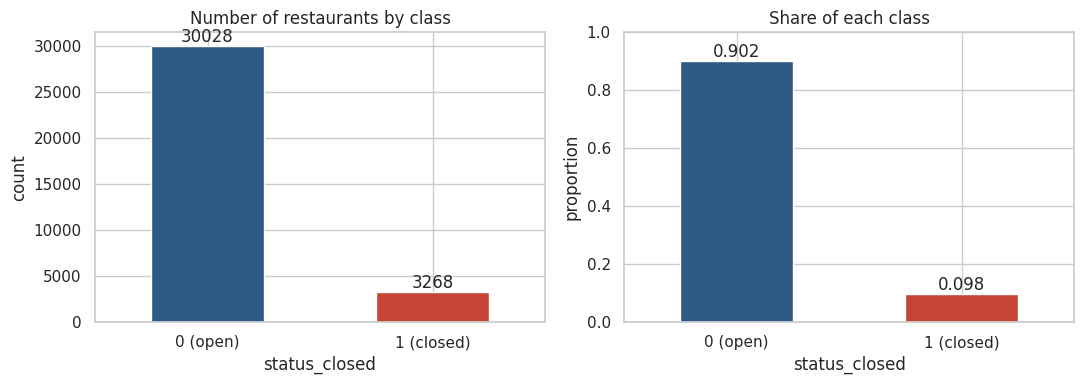

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

counts.plot(kind="bar", ax=ax[0], color=["#2E5984", "#C44536"])
ax[0].set_title("Number of restaurants by class")
ax[0].set_xlabel("status_closed")
ax[0].set_ylabel("count")
ax[0].set_xticklabels(["0 (open)", "1 (closed)"], rotation=0)

proportions.plot(kind="bar", ax=ax[1], color=["#2E5984", "#C44536"])
ax[1].set_title("Share of each class")
ax[1].set_xlabel("status_closed")
ax[1].set_ylabel("proportion")
ax[1].set_xticklabels(["0 (open)", "1 (closed)"], rotation=0)
ax[1].set_ylim(0, 1)

for axis in ax:
    for p in axis.patches:
        axis.annotate(
            f"{p.get_height():.0f}" if axis is ax[0] else f"{p.get_height():.3f}",
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha="center", va="bottom",
        )

plt.tight_layout()
plt.show()

### Why imbalance matters

This is the most important finding from the EDA. The data is very imbalanced, and this changes how we should train and evaluate our models.

If we used **plain accuracy** as our metric, a "lazy" model that just predicts "open" for every restaurant would already reach about 90% accuracy. That sounds great, but the model would be completely useless — it would never find a closed restaurant!

That is why the grading metric is **balanced accuracy**. It is defined as:

$$\text{balanced accuracy} = \frac{\text{sensitivity} + \text{specificity}}{2}$$

where sensitivity is how well we find closed restaurants and specificity is how well we find open ones. The lazy "predict open for everyone" model gets sensitivity = 0 and specificity = 1, so its balanced accuracy is only 0.5 — no better than random guessing.

This gives us a few decisions to take in the modeling notebook:

1. We will set `scoring="balanced_accuracy"` in all cross-validation.
2. We will use `StratifiedKFold` so each fold keeps the same 90/10 ratio.
3. We will use `class_weight="balanced"` in our models. This tells the model to pay more attention to the minority class (closed restaurants) during training.
4. If `class_weight="balanced"` is not enough, we can try resampling techniques like SMOTE (creating synthetic minority-class examples) using the `imblearn` library.

## 3. What types of features do we have?

We have 85 features. To preprocess them properly, we need to know what kind of data is in each column. There are three main types:

- **Numeric** — numbers like ratings, counts, distances.
- **Categorical** — text labels like the type of cuisine.
- **Boolean** — true/false flags.

We use pandas' built-in dtype helpers to split the columns automatically.

In [7]:
from pandas.api.types import is_bool_dtype, is_numeric_dtype

# We do not want to use the ID column or the target as features
feature_cols = [c for c in train.columns if c not in {"restaurant_id", "status_closed"}]

bool_cols = [c for c in feature_cols if is_bool_dtype(train[c])]
numeric_cols = [c for c in feature_cols if is_numeric_dtype(train[c]) and not is_bool_dtype(train[c])]
categorical_cols = [c for c in feature_cols if c not in bool_cols + numeric_cols]

print(f"Numeric features:      {len(numeric_cols)}")
print(f"Categorical features:  {len(categorical_cols)}")
print(f"Boolean features:      {len(bool_cols)}")
print(f"Total:                 {len(feature_cols)}")

Numeric features:      74
Categorical features:  3
Boolean features:      7
Total:                 84


So we have 74 numeric features, 7 boolean features, and 3 categorical ones. Let's look at the categorical columns to see what is inside them.

In [8]:
print("Categorical columns:")
for c in categorical_cols:
    print(f"  {c:30s}  unique values = {train[c].nunique():3d}   examples = {train[c].dropna().unique()[:5].tolist()}")

Categorical columns:
  category_top20                  unique values =  20   examples = ['Kebab', 'Restaurant', 'Pizzeria', 'Pub', 'Other']
  weekends_only                   unique values =   2   examples = [False, True]
  workdays_only                   unique values =   2   examples = [False, True]


Two of these (`weekends_only`, `workdays_only`) are actually yes/no flags stored as text. We will turn them into 0/1 in the preprocessing step.

The most interesting categorical column is `category_top20` — it has 20 different values like "Pizzeria", "Kebab", "Sushi", etc. With only 20 categories, we can safely use **one-hot encoding** (creating one new 0/1 column for each category) without making the dataset too wide.

In [9]:
print("Boolean columns and how often they are True:")
for c in bool_cols:
    pos_rate = train[c].mean()
    print(f"  {c:30s}  share True = {pos_rate:.3f}")

Boolean columns and how often they are True:
  has_photo                       share True = 0.939
  type_meal_takeaway              share True = 0.065
  type_meal_delivery              share True = 0.046
  type_bar                        share True = 0.106
  type_cafe                       share True = 0.024
  type_night_club                 share True = 0.012
  affiliated                      share True = 0.059


These boolean columns describe properties of each restaurant: does it offer takeaway, is it a bar, does it have a photo on its profile, etc. They are already 0/1 so we do not need to do anything special with them.

## 4. Missing values

Real-world data almost always has missing values, and this dataset is no exception. We need to find out where the gaps are and decide what to do with them.

In [10]:
missing = train[feature_cols].isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(2)
missing_table = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_table = missing_table[missing_table["missing_count"] > 0]

print(f"Columns with at least one missing value: {len(missing_table)}")
print("\nTop 20 columns by missingness:")
missing_table.head(20)

Columns with at least one missing value: 54

Top 20 columns by missingness:


,missing_count,missing_pct
tagcat_payment_options,23846,71.62
price_level,16935,50.86
tagcat_social_inclusivity,12712,38.18
ratings_avg_12m_prior,9424,28.30
ratings_num_12m_prior,8345,25.06
ratings_avg_1m_prior,8204,24.64
ratings_avg_9m_prior,6444,19.35
ratings_avg_3m_prior,6189,18.59
ratings_avg_6m_prior,6139,18.44
catch_place_age_days_500m,4956,14.88


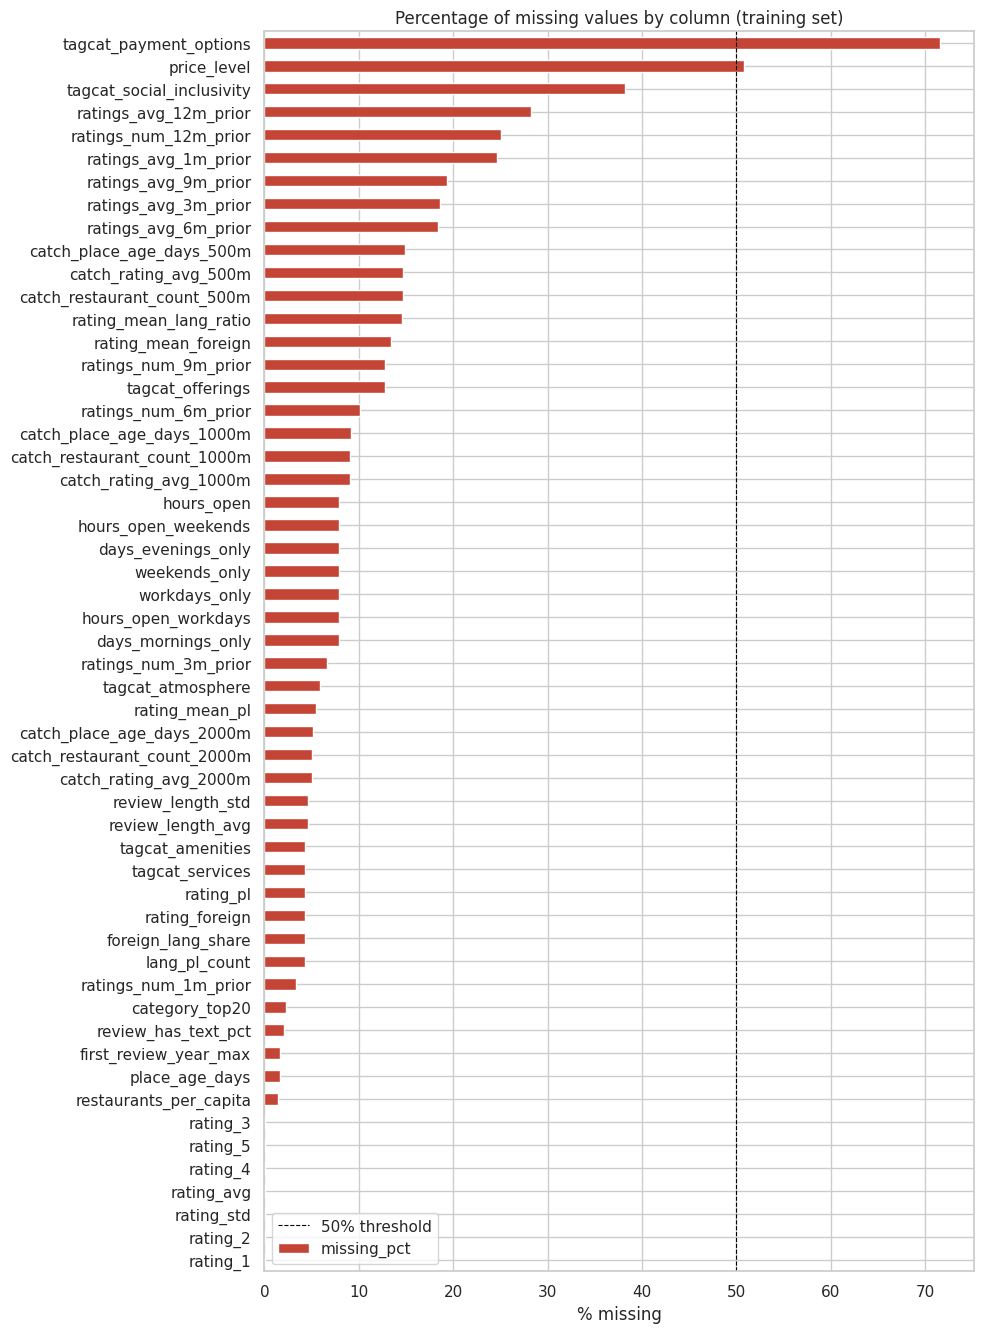

In [11]:
fig, ax = plt.subplots(figsize=(10, max(4, len(missing_table) * 0.25)))
missing_table["missing_pct"].plot(kind="barh", ax=ax, color="#C44536")
ax.invert_yaxis()
ax.set_xlabel("% missing")
ax.set_title("Percentage of missing values by column (training set)")
ax.axvline(50, color="black", linestyle="--", linewidth=0.8, label="50% threshold")
ax.legend()
plt.tight_layout()
plt.show()

### What we see

Some columns have only a few missing values, others have a lot. The worst ones are:

- `tagcat_payment_options` — about 72% missing
- `price_level` — about 51% missing
- `tagcat_social_inclusivity` — about 38% missing

There are also several `ratings_avg_*_prior` and `ratings_num_*_prior` columns with many missing values. These describe the history of ratings for each restaurant; they are probably missing when the restaurant is new and does not have enough rating history yet.

### Our strategy for missing values

We thought about removing the columns with too many missing values, but we decided **not to drop them**, for two reasons:

1. The fact that a value is missing might itself be informative. For example, restaurants that never tell anyone their price level might be different from those that do.
2. Regularization (which our models will use anyway) handles noisy features well, so keeping them does not hurt much.

Instead, we will use **median imputation** for numeric columns (fill missing values with the median) and **most-frequent imputation** for categorical columns. Both methods are simple and robust. We will do this inside a scikit-learn `Pipeline` so it is applied separately on each cross-validation fold (this is important to avoid data leakage).

## 5. How are the numeric features distributed?

Let's plot histograms for a sample of numeric columns. This helps us see if the features are normally distributed, skewed, or have unusual shapes. Many models (especially KNN and SVM) work better when features are on a similar scale, so we will use a `StandardScaler` in our pipeline. But it's still useful to look first.

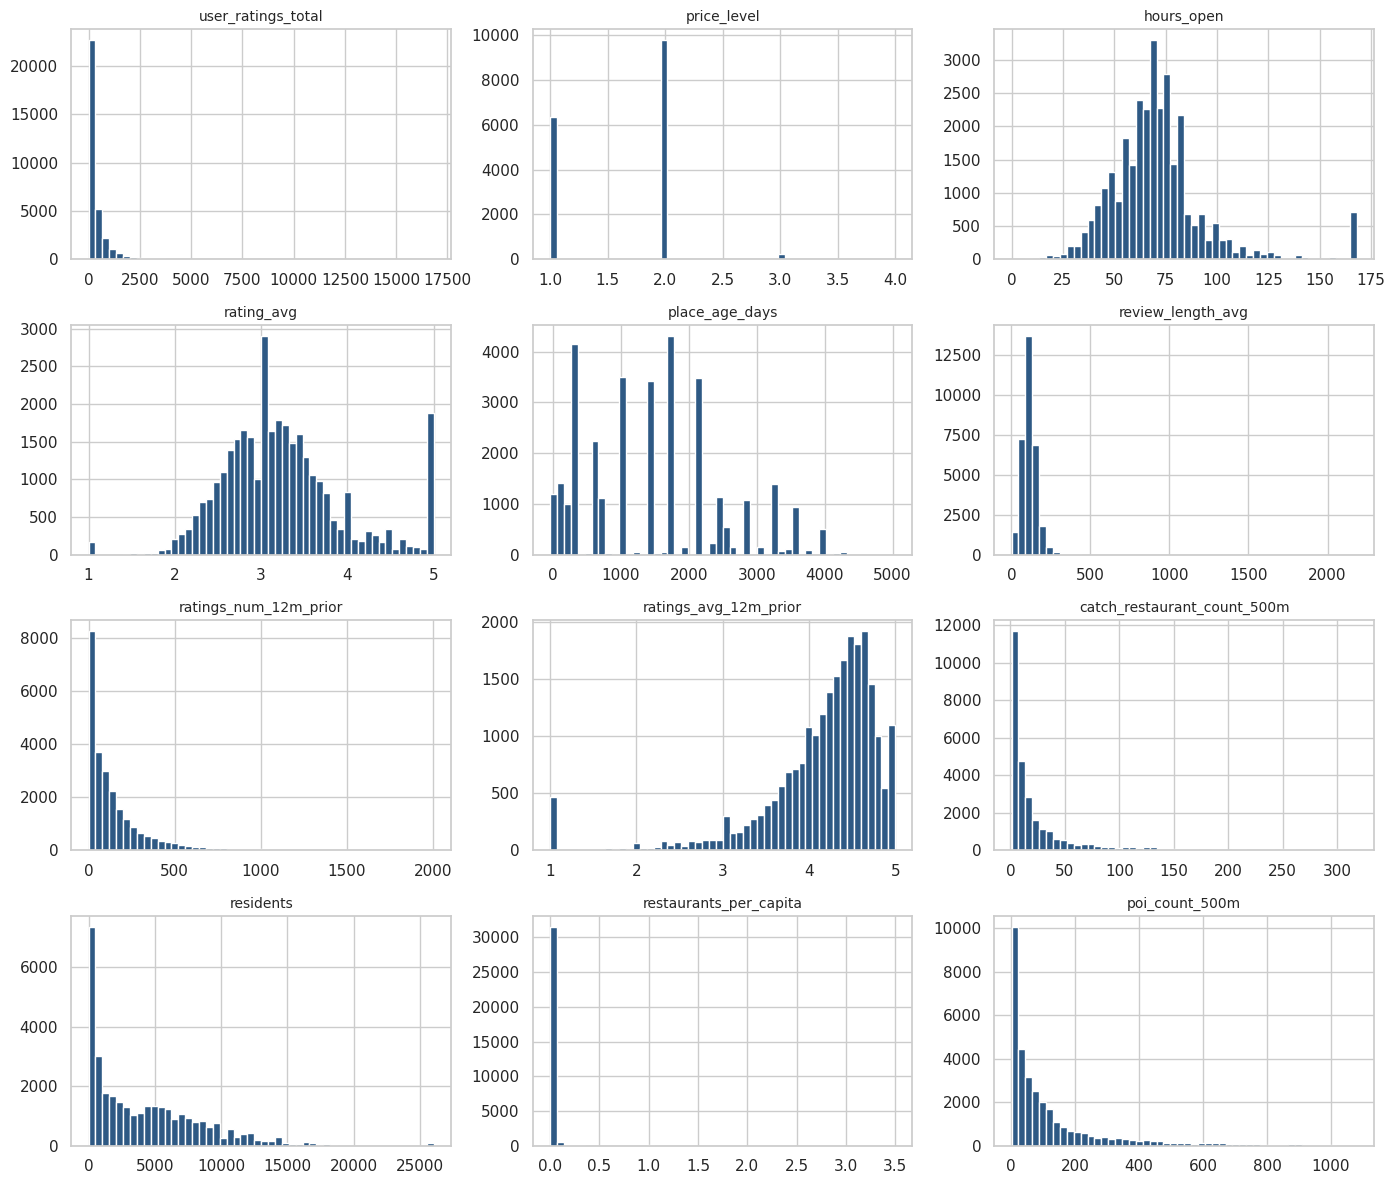

In [12]:
# We pick a small set of representative features so the plot is readable
features_to_plot = [
    "user_ratings_total",
    "price_level",
    "hours_open",
    "rating_avg",
    "place_age_days",
    "review_length_avg",
    "ratings_num_12m_prior",
    "ratings_avg_12m_prior",
    "catch_restaurant_count_500m",
    "residents",
    "restaurants_per_capita",
    "poi_count_500m",
]

fig, axes = plt.subplots(4, 3, figsize=(14, 12))
for ax, col in zip(axes.flat, features_to_plot):
    train[col].hist(ax=ax, bins=50, color="#2E5984")
    ax.set_title(col, fontsize=10)
plt.tight_layout()
plt.show()

Most features are **right-skewed**, meaning they have a long tail to the right. This is normal for count-like variables (`user_ratings_total`, `ratings_num_12m_prior`, `poi_count_500m`). The `rating_avg` and `ratings_avg_12m_prior` columns are more bell-shaped because they are averages on a 1-5 scale.

The `StandardScaler` step in our pipeline will subtract the mean and divide by the standard deviation of each feature, putting them all on a similar scale. This is important because KNN uses distances between points, and SVM is also sensitive to feature scales. Without scaling, features with large values (like `user_ratings_total`, which can be thousands) would dominate features with small values (like `rating_avg`, which is between 1 and 5).

## 6. Which features help separate open from closed restaurants?

This is the most useful part of the EDA. For each feature, we want to see if its distribution is different between open and closed restaurants. If yes, the feature carries signal and our model should be able to use it.

We use **boxplots** because they show the median, the quartiles, and the spread of each group in a compact way.

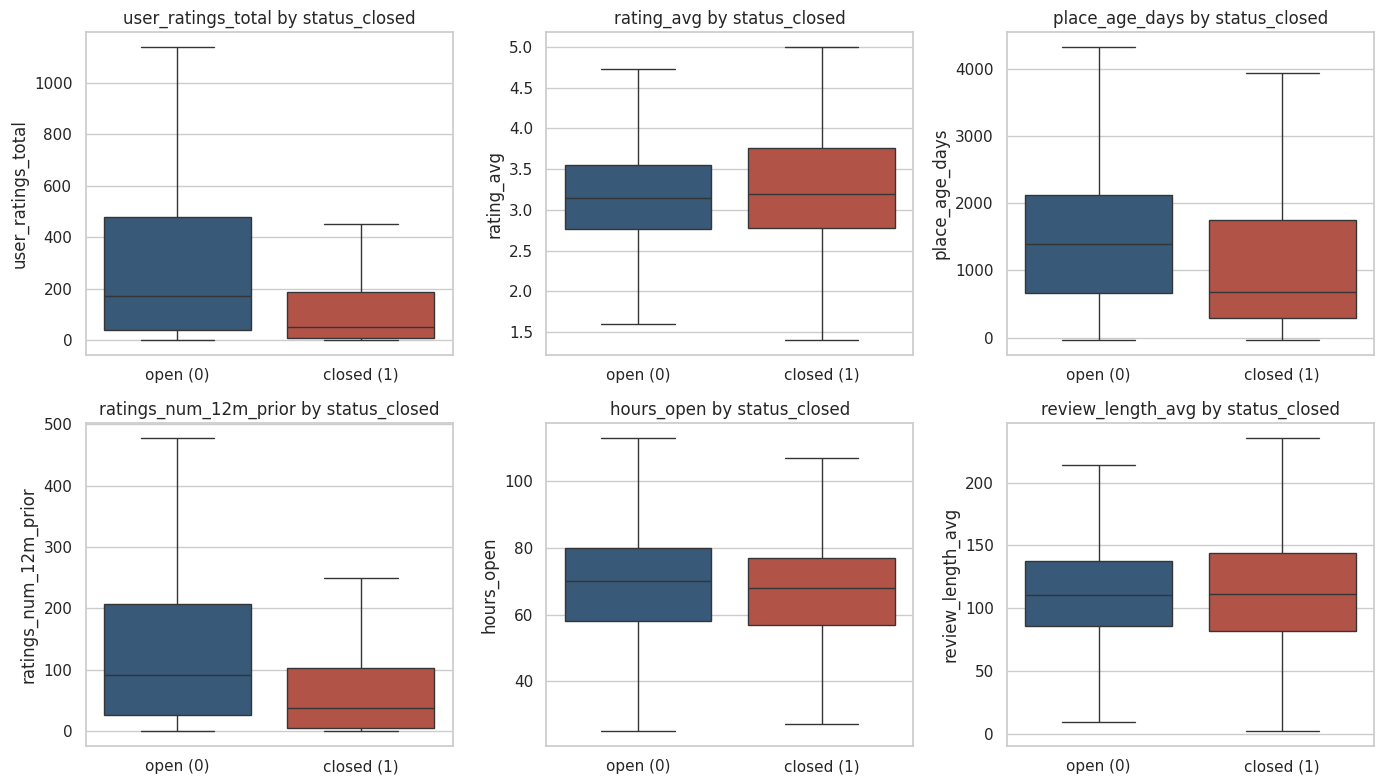

In [13]:
features_vs_target = [
    "user_ratings_total",
    "rating_avg",
    "place_age_days",
    "ratings_num_12m_prior",
    "hours_open",
    "review_length_avg",
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, features_vs_target):
    sns.boxplot(data=train, x=target, y=col, ax=ax, palette=["#2E5984", "#C44536"], showfliers=False)
    ax.set_title(f"{col} by status_closed")
    ax.set_xlabel("")
    ax.set_xticklabels(["open (0)", "closed (1)"])
plt.tight_layout()
plt.show()

### What the plots tell us

- **`user_ratings_total`**: open restaurants have many more user ratings than closed ones. This makes sense — closed restaurants get fewer and fewer reviews over time, and they probably had less engagement to begin with. This is a strong predictor.

- **`ratings_num_12m_prior`**: same story but for the last 12 months only. The difference is even clearer here. Recent activity is a very strong signal.

- **`rating_avg`**: interestingly, the difference is small. Bad ratings on their own do not seem to predict closure very well. A restaurant can have a good average rating and still close (maybe due to low traffic, not low quality).

- **`place_age_days`**: closed restaurants are actually **younger** on average than open ones. This was a bit surprising for us — we initially expected older places to be more likely to close. The likely explanation is that many restaurants close in their first few years, so the population of closed restaurants is dominated by young businesses that did not survive.

- **`hours_open`**: small difference. Probably weak on its own.

- **`review_length_avg`**: also small difference. Probably weak.

So we expect the engagement-based features (number of ratings, number of recent ratings) and the age of the restaurant to be among the most important.

## 7. Does the type of restaurant matter?

Let's check `category_top20`. For each category, we compute the closure rate (what share of restaurants in that category are closed).

In [14]:
cat_summary = (
    train.groupby("category_top20", observed=True)[target]
    .agg(["count", "mean"])
    .rename(columns={"count": "n_restaurants", "mean": "closure_rate"})
    .sort_values("closure_rate", ascending=False)
)
cat_summary

,n_restaurants,closure_rate
category_top20,,
Fast food,1152,0.164931
Kebab,1685,0.143027
Burgers,427,0.128806
Turkish cuisine,259,0.127413
Restaurant with takeaway meals,235,0.119149
Bar and grill,245,0.114286
Bistro,747,0.107095
Healthy food,249,0.104418
Other,4505,0.096337


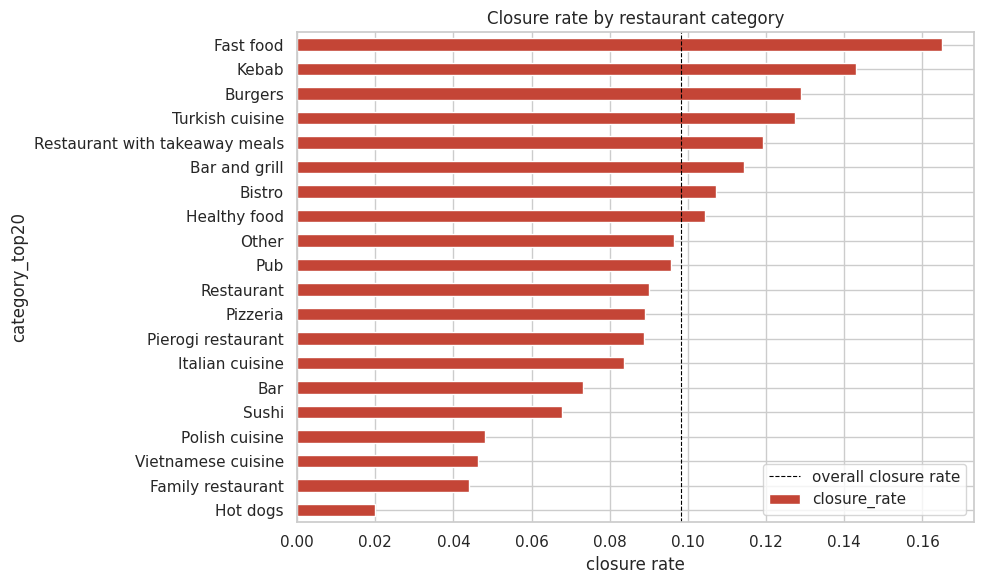

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
cat_summary["closure_rate"].plot(kind="barh", ax=ax, color="#C44536")
ax.invert_yaxis()
ax.axvline(train[target].mean(), color="black", linestyle="--", linewidth=0.8, label="overall closure rate")
ax.set_xlabel("closure rate")
ax.set_title("Closure rate by restaurant category")
ax.legend()
plt.tight_layout()
plt.show()

This is very interesting. The closure rate varies a lot by category:

- **Fast food, Kebab, Burgers, Turkish cuisine** have closure rates above 12% — clearly above the overall average.
- **Hot dogs, Family restaurants, Vietnamese cuisine, Polish cuisine** have closure rates below 5% — much safer.

So the type of restaurant is definitely a useful predictor. We will keep this column and use one-hot encoding for it.

## 8. Are some features correlated with each other?

When two features carry almost the same information (high correlation), the model might struggle to decide which one to use, and the coefficients become unstable. This is called **multicollinearity**.

We do not have to remove correlated features ourselves — we can let **regularization** (Ridge, Lasso, Elastic Net) handle it for us. These methods shrink the coefficients and naturally deal with correlated predictors. But it is still useful to visualize the correlations to understand the data better.

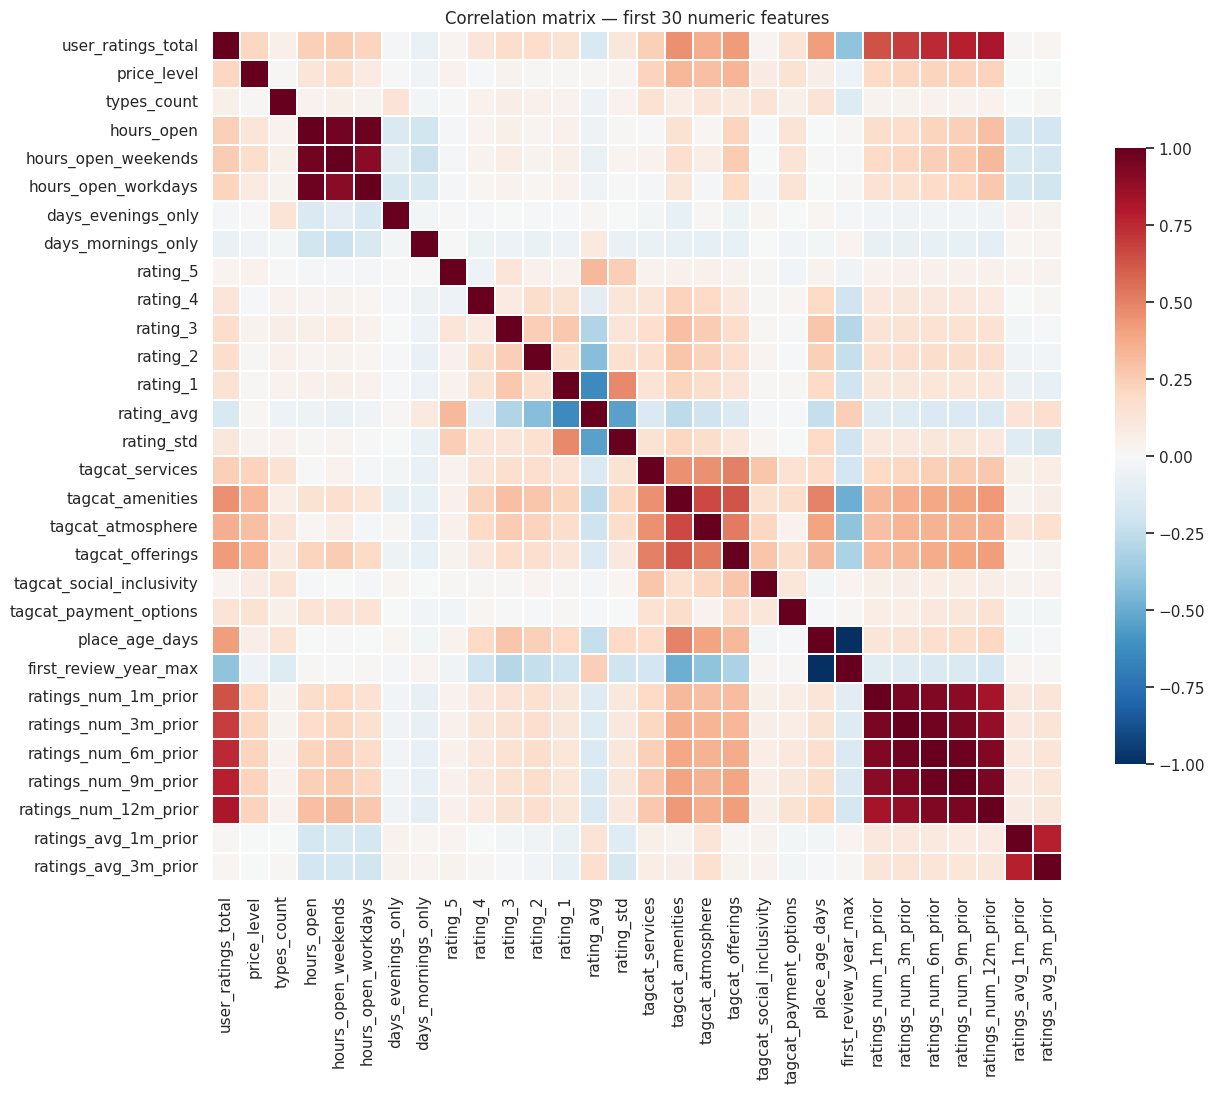

In [16]:
# A heatmap of all 74 numeric features would be unreadable.
# We pick the first 30 to keep the plot interpretable.
numeric_subset = numeric_cols[:30]
corr = train[numeric_subset].corr()

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    corr, ax=ax, cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True,
    cbar_kws={"shrink": 0.7}, linewidths=0.3,
)
ax.set_title("Correlation matrix — first 30 numeric features")
plt.tight_layout()
plt.show()

We can see clear "blocks" of correlated features:

- The `ratings_num_*_prior` family (number of ratings in the last 1, 3, 6, 9, 12 months) — these are correlated by construction, because the 12-month total includes the 1-month total.
- The `ratings_avg_*_prior` family — same logic.
- The `catch_*` family (information about other restaurants within 500m, 1000m, 2000m) — wider radii include narrower ones.

This confirms our decision: we will not try to manually choose which of these correlated columns to keep. Instead, we will use **Elastic Net regularization** in logistic regression. Elastic Net combines L1 (Lasso) and L2 (Ridge) penalties. L1 helps push some coefficients to zero (automatic feature selection), and L2 keeps the model stable when features are correlated. This is exactly the right tool for our situation.

## 9. Summary — what we learned and what to do next

Here is what we found in this EDA:

### Findings

1. The dataset has 33,296 training examples and 85 features.
2. The target is **very imbalanced** (about 90% open, 10% closed).
3. Features are mostly numeric (74), with 3 categorical and 7 boolean columns.
4. Missing values are present in many columns; some columns are missing in over half the rows.
5. The most promising features look like **engagement metrics** (number of ratings, recent activity), **restaurant age**, and **restaurant category**.
6. Many numeric features are correlated in blocks — regularization will help.

### Decisions for the modeling notebook (`02_search.ipynb`)

| Step | Decision | Why |
|---|---|---|
| Metric | `balanced_accuracy` | Matches the Kaggle grading metric |
| Cross-validation | `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` | Keeps the 90/10 ratio in every fold |
| Class imbalance | Start with `class_weight="balanced"`; try SMOTE if it helps | Simple and effective; only add complexity if CV says so |
| Numeric features | Median imputation + StandardScaler | Robust to outliers; scaling is required for KNN and SVM |
| Categorical features | Most-frequent imputation + OneHotEncoder (20 levels for `category_top20`) | Small enough for one-hot |
| Boolean features | Pass through as 0/1 | Already on the right scale |
| Yes/No text columns | Map to 0/1 first | Same as boolean |
| Missing-value strategy | Keep all columns, impute them | Missingness might carry signal |
| Algorithms to compare | **Logistic Regression (Elastic Net)**, **KNN**, **SVM (RBF)** | At least 3 ML1 algorithms required; these cover linear, distance-based, and kernel methods |

### Risks we identified

1. **SVM might be slow** on 33k rows with the RBF kernel. We will benchmark it on a small sample first; if it is too slow, we will fall back to LinearSVC.
2. **KNN may struggle** with so many features (the "curse of dimensionality"). But the syllabus requires us to compare at least three algorithms, and KNN is one of the core ones we learned, so we include it for completeness.

We are now ready to start modeling. See `02_search.ipynb` for the algorithm comparison and hyperparameter tuning.